![Machine Learning Lab](banner.jpg)


# Laboratorio 5 Actividad


## Instrucciones generales


1. Esta actividad debe ser entregada por BN y es de carácter individual. No se permite entregar el laboratorio después de la fecha establecida.
2. Al responder las preguntas de las actividades por favor marcar las respuestas con la sección a la que corresponden, por ejemplo: `## Exploración de datos 2.1`. Es preferible que esto lo hagan con secciones de MarkDown.
3. Por favor nombrar el archivo de acuerdo al siguiente formato `{email}_lab5.ipynb`.
4. Si tienen alguna duda pueden escribirme a mi correo `j.rayom@uniandes.edu.co` o contactarme directamente por Teams

### 0\. Descarga del dataset

Utiliza el siguiente enlace para descargar el dataset de Twitter Tweets Sentiment:

[Descargar Dataset](https://www.kaggle.com/datasets/yasserh/twitter-tweets-sentiment-dataset)

El dataset contiene tweets reales con clasificación de sentimiento en 3 clases (positive/negative/neutral)


### 1\. Exploración de datos (5%)

1. **Carga del dataset**:
   - Cargar el dataset
   - Seleccionar solo las columnas necesarias: `text` y `sentiment`
   - Eliminar filas con valores faltantes

2. **Análisis exploratorio**:
   - Analizar las primeras 10 filas del dataset limpio
   - Mostrar la distribución de clases (Positive, Negative, Neutral)
   - Verificar el tamaño final del dataset


### 2\. Procesamiento de datos (15%)

Los algoritmos de Machine Learninng no trabajan directamente con texto. Por eso debemos convertir palabras en vectores numéricos mediante técnicas como [Bag-of-Words](https://www.ibm.com/think/topics/bag-of-words), un método que cuantifica la frecuencia de palabras en documentos de texto. Esto transforma frases como "muy muy mala pelicula" en vectores como [0, 2, 1, 1, 0, 0, ..., 0] donde cada posición representa una palabra del vocabulario.

Scikit-learn provee una clase [`CountVectorizer`](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) que convierte una colección de documentos a una matriz de conteo de palabras. Adicionalmente, realiza procesamiento convirtiendo el texto a minúsculas y eliminando palabras que no aportan valor a la predicción.

1. Divide el dataset en 80/20 con `train_test_split()`, `stratify=sentiment`, y `random_state=42`.
2. Usa CountVectorizer usando `lowercase=True` y `stop_words='english'` e inicializalo con el conjunto de entrenamiento usando `fit_transform`
   
   ```python
   from sklearn.feature_extraction.text import CountVectorizer
   
   # Vectorizador automático
   vectorizer = CountVectorizer(lowercase=True, stop_words='english')
   
   ...
   ```
3. Compara 3 textos originales con el texto procesado por `CountVectorizer`.

### 3\. Entrenamiento de Naïve Bayes (60%)

1. **Entrenamiento de modelos**:
   - Entrena un modelo de [MultinomialNB](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html) (para frecuencias de palabras)
   - Entrena un modelo de [BernoulliNB](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.BernoulliNB.html) (para presencia/ausencia de palabras)

2. **Evaluación y métricas**:
   - Reporta **accuracy**, **precision**, **recall**, y **F1-score** de cada modelo

3. **Análisis comparativo**:
   - ¿Qué modelo obtuvo el mejor rendimiento?

### 4\. Predicciones (20%)

1. Realiza 3 predicciones con el mejor modelo sobre nuevos tweets que demuestren como clasifica el modelo el texto para cada una de las clases.

---

### 1. Exploración de datos

Carga del conjunto de datos **Twitter Tweets Sentiment** en un DataFrame de **Pandas**

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
tweets_data = pd.read_csv("../datasets/tweets.csv")

In [3]:
tweets_data.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


Selección de las columnas necesarias (**text** y **sentiment**) para llevar a cabo el proceso de clasificación de sentimientos

In [4]:
tweets_data = tweets_data[["text", "sentiment"]]

In [5]:
tweets_data.head()

,text,sentiment
0,"I`d have responded, if I were going",neutral
1,Sooo SAD I will miss you here in San Diego!!!,negative
2,my boss is bullying me...,negative
3,what interview! leave me alone,negative
4,"Sons of ****, why couldn`t they put them on t...",negative


Eliminación de las filas con valores faltantes en cualquierda de las dos columnas seleccionadas (**text** y **sentiment**)

In [7]:
tweets_data.isna().sum()

text         1
sentiment    0
dtype: int64

In [8]:
tweets_data = tweets_data.dropna(subset = ["text", "sentiment"])

In [9]:
tweets_data.isna().sum()

text         0
sentiment    0
dtype: int64

Visualización de las 10 primeras filas del conjunto de datos luego del proceso de limpieza

In [10]:
tweets_data.head(n = 10)

,text,sentiment
0,"I`d have responded, if I were going",neutral
1,Sooo SAD I will miss you here in San Diego!!!,negative
2,my boss is bullying me...,negative
3,what interview! leave me alone,negative
4,"Sons of ****, why couldn`t they put them on t...",negative
5,http://www.dothebouncy.com/smf - some shameles...,neutral
6,2am feedings for the baby are fun when he is a...,positive
7,Soooo high,neutral
8,Both of you,neutral
9,Journey!? Wow... u just became cooler. hehe....,positive


| Pregunta | Respuesta |
|----------|------------|
| Analizar las primeras diez filas del conjunto de datos limpio | Las primeras diez filas muestran que el dataset contiene textos cortos tipo tweet y una etiqueta de sentimiento asociada (**positive**, **negative**, **neutral**). En esta muestra predominan los sentimientos negativos (4 de 10), seguidos por neutrales (4 de 10) y positivos (2 de 10). Los textos son informales, incluyen expresiones emocionales en mayúsculas (“SAD”), signos de exclamación, enlaces web y lenguaje coloquial. Esto indica que se trata de datos reales de redes sociales, con ruido típico como abreviaciones, puntuación irregular y contenido variado, lo cual puede requerir preprocesamiento adicional antes de entrenar un modelo.  |

Visualización de la distribución de clases de la variable objetivo **sentiment**

In [12]:
tweets_data["sentiment"].value_counts()

sentiment
neutral     11117
positive     8582
negative     7781
Name: count, dtype: int64

In [13]:
tweets_data["sentiment"].value_counts(normalize = True) * 100

sentiment
neutral     40.454876
positive    31.229985
negative    28.315138
Name: proportion, dtype: float64

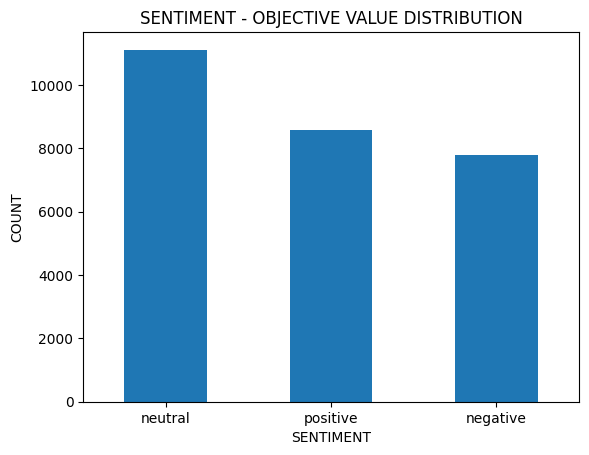

In [14]:
tweets_data["sentiment"].value_counts().plot(kind = "bar")

plt.title("SENTIMENT - OBJECTIVE VALUE DISTRIBUTION")
plt.xlabel("SENTIMENT")
plt.ylabel("COUNT")
plt.xticks(rotation = 0)
plt.show()

Verificación del tamaño final del conjunto de datos

In [16]:
print("ROWS = ", tweets_data.shape[0])
print("COLUMNS = ", tweets_data.shape[1])

ROWS =  27480
COLUMNS =  2


### 2. Procesamiento de datos

In [25]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

Separación de la variable objetivo **sentiment** del resto de variables presentes en el conjunto de datos

In [17]:
X = tweets_data.drop("sentiment", axis = 1)
y = tweets_data["sentiment"]

In [20]:
X.columns

Index(['text'], dtype='object')

División del conjunto de datos en conjuntos de entrenamiento y prueba, estratificando las divisiones usando las clases presentes en la variable objetivo **sentiment** 

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

Creación de la representación de texto **Bag of Words** haciendo uso de la clase **CountVectorizer** ajustada sobre el conjunto de entrenamiento

In [36]:
vectorizer = CountVectorizer(lowercase = True, stop_words = "english")

In [37]:
X_train_vect = vectorizer.fit_transform(X_train["text"])

In [38]:
X_test_vect = vectorizer.transform(X_test["text"])

Comparación de tres textos representados mediante **Bag of Words** con respecto a su representación original

In [42]:
feature_names = vectorizer.get_feature_names_out()

In [45]:
for i in range(3):

    text = X_train.iloc[i]["text"]  
    
    print(f"\nORIGINAL TEXT {i+1}:\n")
    print(text)
    
    vector = vectorizer.transform([texto])
    
    print("\nBAG OF WORDS (WORD -> FREQUENCY):\n")
    
    for idx in vector.nonzero()[1]:
        print(f"{feature_names[idx]} -> {vector[0, idx]}")
    
    print()
    print("************ ============ ************")


ORIGINAL TEXT 1:

 Press `Ctrl` on bottom right. It`s there.  KY

BAG OF WORDS (WORD -> FREQUENCY):

2morrow -> 1
2night -> 1
comin -> 1
day -> 1
momma -> 1
nar -> 1
tennis -> 1
yuppie -> 1

************ ============ ************

ORIGINAL TEXT 2:

ah remember the days when you`d sleep in until noon? well guess who did that today? god i feel like a loser

BAG OF WORDS (WORD -> FREQUENCY):

2morrow -> 1
2night -> 1
comin -> 1
day -> 1
momma -> 1
nar -> 1
tennis -> 1
yuppie -> 1

************ ============ ************

ORIGINAL TEXT 3:

my momma is comin 2night !  2morrow tennis day with p?nar yuppie !

BAG OF WORDS (WORD -> FREQUENCY):

2morrow -> 1
2night -> 1
comin -> 1
day -> 1
momma -> 1
nar -> 1
tennis -> 1
yuppie -> 1

************ ============ ************


| Pregunta | Respuesta |
|----------|------------|
| Compare 3 textos originales con el texto procesado | Al comparar los textos originales con su representación procesada mediante **CountVectorizer**, se observa que el texto se normaliza convirtiéndose completamente a minúsculas. Además, se eliminan las stopwords en inglés (como the, is, when, who, that), así como signos de puntuación y caracteres especiales. Posteriormente, el texto se tokeniza, es decir, se divide en palabras individuales relevantes. Finalmente, se construye la representación **Bag of Words**, donde cada posición del vector corresponde a un token del vocabulario global aprendido en el conjunto de entrenamiento, y el valor en esa posición indica la frecuencia con la que esa palabra aparece en el texto. De esta forma, el texto deja de ser una secuencia lingüística y pasa a representarse como un vector numérico basado en conteo de palabras.|